Need to run a cleaning script on the output of our existing lidar data analysis


- Want to remove "pocket parks"
- Want to recalulate the data to just be a single point in the centroid of the hex vs the full hex
- Want to test different output options and plotting


In [35]:
import pandas as pd
import os
import glob
import geopandas as gpd

import folium
import matplotlib.pyplot as plt

In [36]:
# start by setting up a simple import/list of files
folders = glob.glob("../workflow_outputs/*")


In [37]:
folders

['../workflow_outputs/Windsor and Maidenhead_pp_or_g_cmb',
 '../workflow_outputs/Blackburn with Darwen_pp_or_g_cmb',
 '../workflow_outputs/Swale_pp_or_g_cmb',
 '../workflow_outputs/Rushmoor_pp_or_g_cmb',
 '../workflow_outputs/Cumberland_pp_or_g_cmb',
 '../workflow_outputs/Wiltshire_pp_or_g_cmb',
 '../workflow_outputs/Canterbury_pp_or_g_cmb',
 '../workflow_outputs/Pendle_pp_or_g_cmb',
 '../workflow_outputs/Thurrock_pp_or_g_cmb',
 '../workflow_outputs/Rutland_pp_or_g_cmb',
 '../workflow_outputs/Eastleigh_pp_or_g_cmb',
 '../workflow_outputs/Teignbridge_pp_or_g_cmb',
 '../workflow_outputs/Derby_pp_or_g_cmb',
 '../workflow_outputs/Colchester_pp_or_g_cmb',
 '../workflow_outputs/Rother_pp_or_g_cmb',
 '../workflow_outputs/Basingstoke and Deane_pp_or_g_cmb',
 '../workflow_outputs/Buckinghamshire_pp_or_g_cmb',
 '../workflow_outputs/East Riding of Yorkshire_pp_or_g_cmb',
 '../workflow_outputs/Bath and North East Somerset_pp_or_g_cmb',
 '../workflow_outputs/Havant_pp_or_g_cmb',
 '../workflow_outpu

In [38]:
# just starting with the very first

folders[0]

'../workflow_outputs/Windsor and Maidenhead_pp_or_g_cmb'

In [39]:
park_files_batch = glob.glob(f"{folders[0]}/*")

In [40]:
park_files_batch[0]

'../workflow_outputs/Windsor and Maidenhead_pp_or_g_cmb/d560a130dd33_visibility.geojson'

In [41]:
example_loaded = gpd.read_file(park_files_batch[0])

In [42]:
example_loaded.head()

,visible_points,total_points,visibility_pct,geometry
0,0,66,0.000000,"POLYGON ((-0.64626 51.46541, -0.64636 51.46544..."
1,0,67,0.000000,"POLYGON ((-0.64606 51.4654, -0.64616 51.46544,..."
2,2,77,2.597403,"POLYGON ((-0.64636 51.46551, -0.64646 51.46555..."
3,0,78,0.000000,"POLYGON ((-0.64616 51.46551, -0.64626 51.46555..."
4,0,79,0.000000,"POLYGON ((-0.64596 51.46551, -0.64606 51.46555..."


In [43]:
# I want to quickly estimate the size of the hexagons, just a sample of a few to calculate

# will have to reproject crs to get area in m2

hexes_reprojected = example_loaded.to_crs("EPSG:32610")
hexes_reprojected["area_m2"] = hexes_reprojected.area

In [44]:
hexes_reprojected.head()

,visible_points,total_points,visibility_pct,geometry,area_m2
0,0,66,0.000000,"POLYGON ((4236991.47 12570918.116, 4236992.765...",229.860062
1,0,67,0.000000,"POLYGON ((4236981.459 12570930.969, 4236982.75...",229.859671
2,2,77,2.597403,"POLYGON ((4236985.344 12570903.02, 4236986.639...",229.859777
3,0,78,0.000000,"POLYGON ((4236975.333 12570915.873, 4236976.62...",229.859385
4,0,79,0.000000,"POLYGON ((4236965.322 12570928.725, 4236966.61...",229.858994


we're defining pocket parks as <=0.5 ha, (5000 m2)

I'll give a little wiggle room and include vga for parks over 4500?

In [45]:
size_cutoff = 4500
hex_size = hexes_reprojected["area_m2"].mean()

hexes_cutoff = size_cutoff/hex_size

In [46]:
hexes_cutoff

np.float64(19.577225504123838)

In [47]:
# will round this up to 20; parks have to have 20 or more hexes.

In [48]:
print(len(park_files_batch))

final_parks = []

for i in park_files_batch:
    park = gpd.read_file(i)
    if len(park) >= 20:
        print(f"{i} has {len(park)} hexes, which is above the cutoff of 20.")
        final_parks.append(i)
    else:
        print(f"{i} has {len(park)} hexes, which is below the cutoff of 20.")

438
../workflow_outputs/Windsor and Maidenhead_pp_or_g_cmb/d560a130dd33_visibility.geojson has 122 hexes, which is above the cutoff of 20.
../workflow_outputs/Windsor and Maidenhead_pp_or_g_cmb/9ae323fe3541_visibility.geojson has 1979 hexes, which is above the cutoff of 20.
../workflow_outputs/Windsor and Maidenhead_pp_or_g_cmb/8d69257c0573_visibility.geojson has 260 hexes, which is above the cutoff of 20.
../workflow_outputs/Windsor and Maidenhead_pp_or_g_cmb/102a73f21185_foliage.geojson has 13 hexes, which is below the cutoff of 20.
../workflow_outputs/Windsor and Maidenhead_pp_or_g_cmb/019aff4f8789_foliage.geojson has 2772 hexes, which is above the cutoff of 20.
../workflow_outputs/Windsor and Maidenhead_pp_or_g_cmb/5dca18ead640_visibility.geojson has 325 hexes, which is above the cutoff of 20.
../workflow_outputs/Windsor and Maidenhead_pp_or_g_cmb/af465f7a34fb_visibility.geojson has 7 hexes, which is below the cutoff of 20.
../workflow_outputs/Windsor and Maidenhead_pp_or_g_cmb/f6c

In [49]:
print(len(park_files_batch))
print(len(final_parks))

438
228


<Axes: >

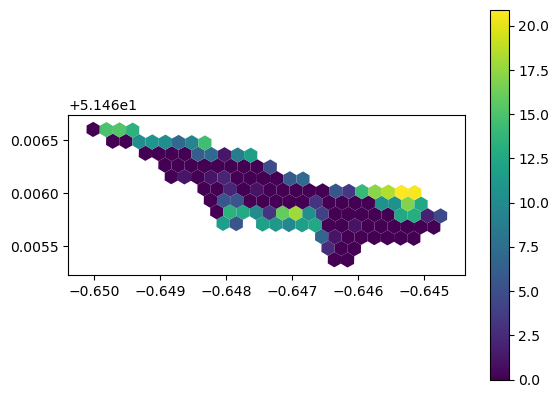

In [50]:
example_loaded.plot(column='visibility_pct', cmap='viridis', legend=True)

In [51]:
# plotting the hexes on a map - locations only to check

m = folium.Map()

folium.GeoJson(
    example_loaded,
    style_function=lambda x: {
        'fillColor': 'blue',
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.3
    }
).add_to(m)

# m.show_in_browser()

In [52]:
# Test: Convert hexagons to centroids and plot
# Extract centroids from the hex polygons
example_centroids = example_loaded.copy()
example_centroids['geometry'] = example_centroids.geometry.centroid

# Plot centroids on the map
m2 = folium.Map([51.6, -0.647], zoom_start=12)

# Add centroids as circle markers
for idx, row in example_centroids.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=5,
        popup=f"Hex {idx}",
        color='red',
        fill=True,
        fillColor='red',
        fillOpacity=0.7
    ).add_to(m2)

# m2.show_in_browser()

/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_28217/3096989882.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  example_centroids['geometry'] = example_centroids.geometry.centroid


In [53]:

# Save as GeoJSON
example_loaded.to_file('test_polygon.geojson', driver='GeoJSON')
example_centroids.to_file('test_centroids.geojson', driver='GeoJSON') 
geojson_size_poly = os.path.getsize('test_polygon.geojson')
geojson_size_point = os.path.getsize('test_centroids.geojson')

# Save as GeoParquet
example_loaded.to_parquet('test_polygon.parquet')
parquet_size = os.path.getsize('test_polygon.parquet')

print(f"GeoJSON (polygon): {geojson_size_poly / 1024 / 1024:.2f} MB")
print(f"GeoJSON (centroid): {geojson_size_point / 1024 / 1024:.2f} MB")
print(f"GeoParquet (polygon): {parquet_size / 1024 / 1024:.2f} MB")


GeoJSON (polygon): 0.06 MB
GeoJSON (centroid): 0.02 MB
GeoParquet (polygon): 0.02 MB


In [54]:
example_loaded.geometry

0      POLYGON ((-0.64626 51.46541, -0.64636 51.46544...
1      POLYGON ((-0.64606 51.4654, -0.64616 51.46544,...
2      POLYGON ((-0.64636 51.46551, -0.64646 51.46555...
3      POLYGON ((-0.64616 51.46551, -0.64626 51.46555...
4      POLYGON ((-0.64596 51.46551, -0.64606 51.46555...
                             ...                        
117    POLYGON ((-0.64822 51.46651, -0.64832 51.46654...
118    POLYGON ((-0.64992 51.46663, -0.65001 51.46667...
119    POLYGON ((-0.64972 51.46663, -0.64981 51.46667...
120    POLYGON ((-0.64952 51.46663, -0.64961 51.46667...
121    POLYGON ((-0.64932 51.46663, -0.64942 51.46667...
Name: geometry, Length: 122, dtype: geometry

In [55]:
from shapely.geometry import Point

# Reproject to a projected CRS first (same as your area calculation)
example_loaded_projected = example_loaded.to_crs("EPSG:32610")

def get_hex_radius_from_polygon(polygon):
    """Calculate circumradius of a hexagon polygon"""
    centroid = polygon.centroid
    first_vertex = Point(polygon.exterior.coords[0])
    radius = centroid.distance(first_vertex)  # Now in meters!
    return radius

example_loaded_projected['hex_radius_m'] = example_loaded_projected.geometry.apply(get_hex_radius_from_polygon)

print(f"Mean radius: {example_loaded_projected['hex_radius_m'].mean():.2f} m")
print(f"Std dev: {example_loaded_projected['hex_radius_m'].std():.6f} m")
print(f"Min: {example_loaded_projected['hex_radius_m'].min():.2f} m")
print(f"Max: {example_loaded_projected['hex_radius_m'].max():.2f} m")

Mean radius: 9.41 m
Std dev: 0.000044 m
Min: 9.41 m
Max: 9.41 m


In [56]:
# Use British National Grid instead
example_loaded_projected = example_loaded.to_crs("EPSG:27700")  # UK-specific
hexes_reprojected = example_loaded_projected
hexes_reprojected['hex_radius_m'] = hexes_reprojected.geometry.apply(
    lambda polygon: polygon.centroid.distance(Point(polygon.exterior.coords[0]))
)
print(f"Mean radius: {hexes_reprojected['hex_radius_m'].mean():.2f} m")
print(f"Mean radius: {example_loaded_projected['hex_radius_m'].mean():.2f} m")
print(f"Std dev: {example_loaded_projected['hex_radius_m'].std():.6f} m")
print(f"Min: {example_loaded_projected['hex_radius_m'].min():.2f} m")
print(f"Max: {example_loaded_projected['hex_radius_m'].max():.2f} m")

Mean radius: 8.00 m
Mean radius: 8.00 m
Std dev: 0.000000 m
Min: 8.00 m
Max: 8.00 m


In [ ]:
example_centroids_with_radius = example_centroids.copy()
example_centroids_with_radius['hex_radius_m'] = example_loaded_projected['hex_radius_m'].values

In [ ]:

# Save as GeoJSON
example_loaded.to_file('test_polygon.geojson', driver='GeoJSON')
example_centroids.to_file('test_centroids.geojson', driver='GeoJSON')
example_centroids_with_radius.to_file('test_centroids_with_radius.geojson', driver='GeoJSON')
geojson_size_poly = os.path.getsize('test_polygon.geojson')
geojson_size_point = os.path.getsize('test_centroids.geojson')
geojson_size_point_with_r = os.path.getsize('test_centroids_with_radius.geojson')

# Save as GeoParquet
example_loaded.to_parquet('test_polygon.parquet')
parquet_size = os.path.getsize('test_polygon.parquet')

print(f"GeoJSON (polygon): {geojson_size_poly / 1024 / 1024:.2f} MB")
print(f"GeoJSON (centroid): {geojson_size_point / 1024 / 1024:.2f} MB")
print(f"GeoJSON (centroid with radius): {geojson_size_point_with_r / 1024 / 1024:.2f} MB")
print(f"GeoParquet (polygon): {parquet_size / 1024 / 1024:.2f} MB")


GeoJSON (polygon): 0.06 MB
GeoJSON (centroid): 0.02 MB
GeoJSON (centroid with radius): 0.03 MB
GeoParquet (polygon): 0.02 MB


In [58]:
import json

metadata = {
    "hex_radius_m": 8.0,
    "dataset_name": "UK Parks VGA Analysis",
    "crs_original": "EPSG:4326",
    "notes": "Constant across all analyses"
}

with open('dataset_metadata.json', 'w') as f:
    json.dump(metadata, f)

In [60]:
# estimate the total size of the workflow_outputs folder:
import os

def get_dir_size(path):
    """Calculate total directory size in bytes"""
    total = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for filename in filenames:
            filepath = os.path.join(dirpath, filename)
            try:
                total += os.path.getsize(filepath)
            except (OSError, FileNotFoundError):
                pass
    return total

def human_readable_size(size_bytes):
    """Convert bytes to human-readable format"""
    for unit in ['B', 'KB', 'MB', 'GB', 'TB']:
        if size_bytes < 1024:
            return f"{size_bytes:.2f} {unit}"
        size_bytes /= 1024
    return f"{size_bytes:.2f} PB"

path = "../workflow_outputs"
size_bytes = get_dir_size(path)
print(f"Actual directory size: {human_readable_size(size_bytes)}")

Actual directory size: 8.52 GB
